# 05 Visualização Espacial da Incerteza (Heatmap KDE)

**Objetivo:** Explorar os padrões espaciais dos registros que apresentaram baixíssima probabilidade de acerto ou ficaram órfãos (MCI < 0.5). A hipótese é que essas áreas correspondam a aglomerados subnormais, áreas de expansão recente ou zonas rurais/vazios urbanos do município de Belo Horizonte.

**Entradas:**
- `data/interim/cnefe_match_bhmap.parquet`


In [1]:
import sys
import os
from pathlib import Path

os.chdir('..')
sys.path.append(os.getcwd())

%load_ext autoreload
%autoreload 2

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from src import config
from src.maps import plot_kde_heatmap


## 1. Carregamento dos Dados
Vamos extrair apenas os pontos problemáticos da integração.

In [2]:
print("Lendo a base espacial do CNEFE cruzada...")
gdf_matched = gpd.read_parquet(config.INTERIM_DATA_DIR / "cnefe_match_bhmap.parquet")

print(f"Total na base: {len(gdf_matched):,}")

# Definimos "Alta Incerteza" como MCI abaixo de 0.5 (incluindo os 0.0 que são os orfãos definitivos)
low_certainty = gdf_matched[gdf_matched['MCI'] < 0.5].copy()
print(f"Registros de Alta Incerteza (MCI < 0.5): {len(low_certainty):,}")


Lendo a base espacial do CNEFE cruzada...


Total na base: 1,180,102
Registros de Alta Incerteza (MCI < 0.5): 134,840


## 2. Geração do Mapa de Calor (Kernel Density Estimation)
Utilizaremos a biblioteca de visualização helper para plotar no mapa a concentração matemática de erros de cruzamento. Áreas mais vermelhas indicam "hotspots" críticos do censo frente à base de prefeitura.

Saved heatmap to C:\Users\mateu\OneDrive\Documentos\UFMG\Mestrado\geocoding-quality-analysis\outputs\maps\05_low_certainty_mci_heatmap.png


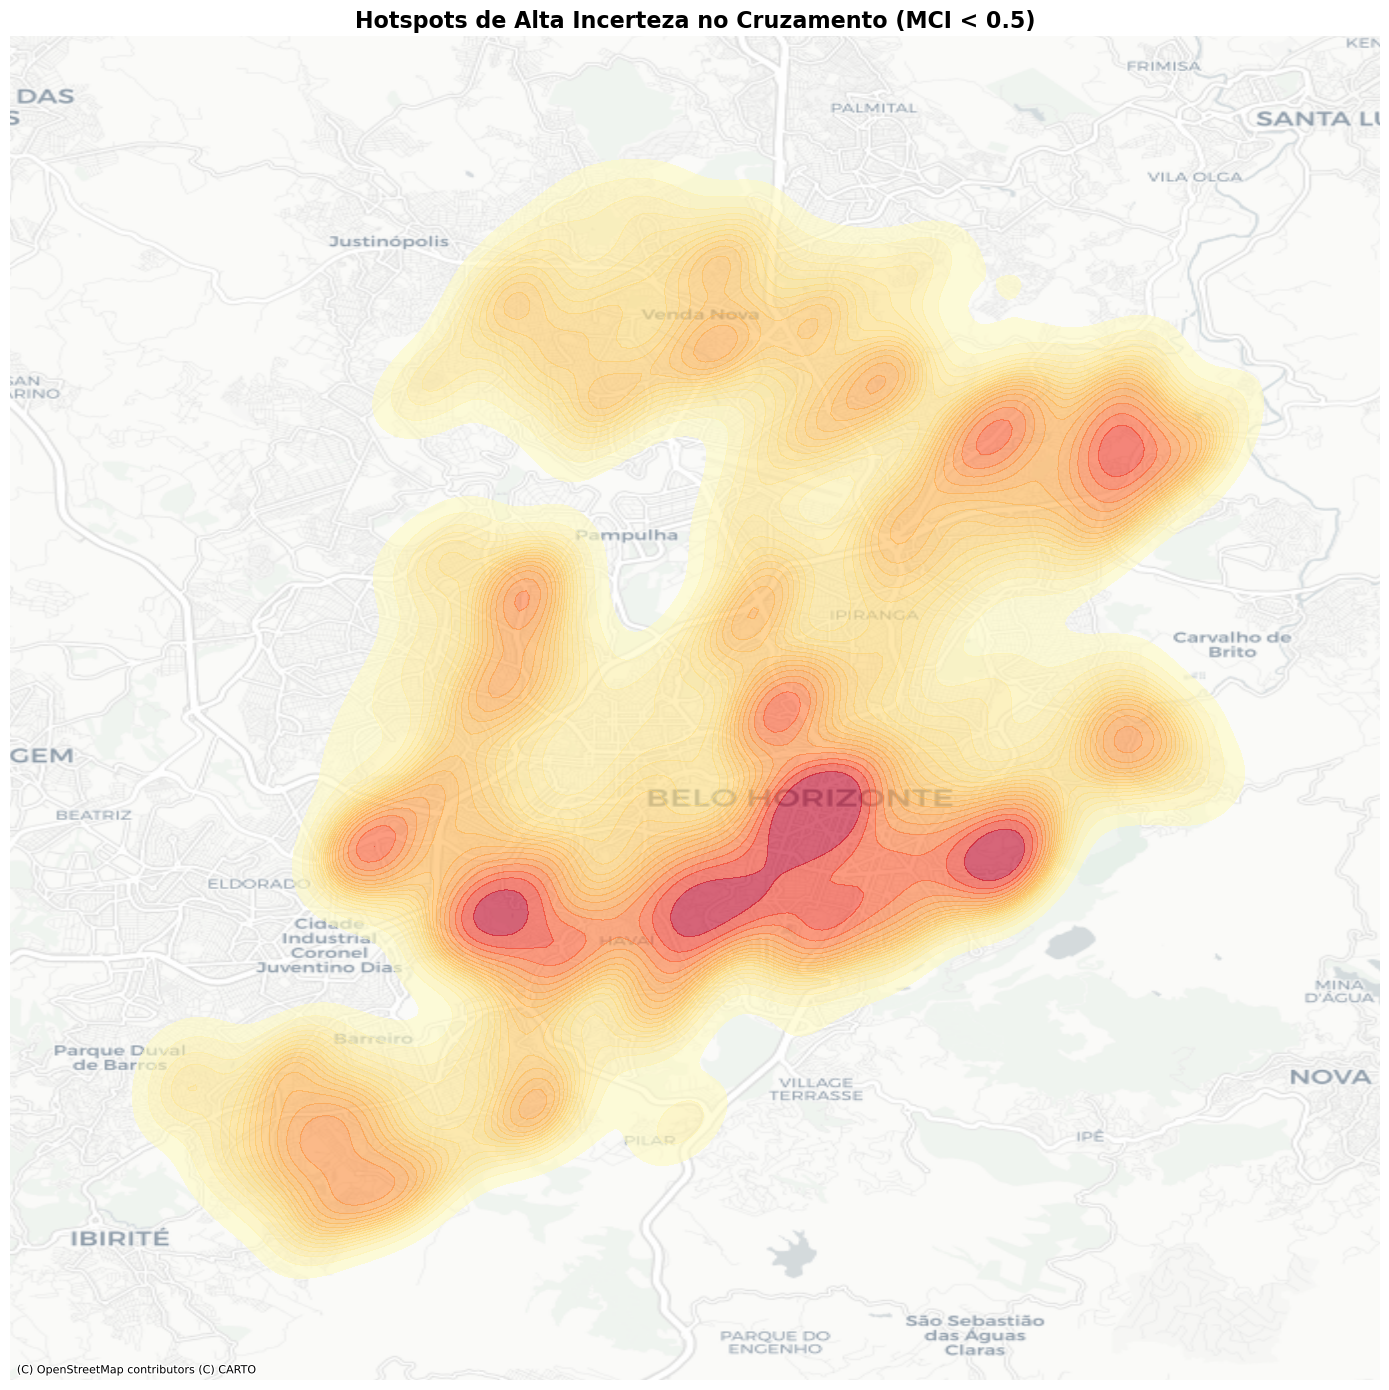

In [3]:
# Esse processo pode demorar alguns segundos dependendo da quantidade de pontos
fig, ax = plot_kde_heatmap(
    gdf=low_certainty,
    output_path=str(config.MAPS_DIR / "05_low_certainty_mci_heatmap.png"),
    title="Hotspots de Alta Incerteza no Cruzamento (MCI < 0.5)",
    cmap="YlOrRd",
    alpha=0.6,
    figsize=(14, 14),
    add_basemap=True
)
